In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [2]:
# convert csv to dataframe
df=pd.read_csv("combined_df_1.csv")
df

,it,ft,bt,transmission,ownerNo,oem,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Engine,Seats_1,Color,Gear Box,Drive Type,City
0,0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,₹ 4 Lakh,Third Party insurance,"1,20,000 Kms",23.1 kmpl,998 CC,5.0,White,5 Speed,FWD,Bangalore
1,0,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,₹ 8.11 Lakh,Comprehensive,"32,706 Kms",17 kmpl,1497 CC,5.0,White,5 Speed,FWD,Bangalore
2,0,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,₹ 5.85 Lakh,Comprehensive,"11,949 Kms",23.84 kmpl,1199 CC,5.0,Red,5 Speed,FWD,Bangalore
3,0,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,₹ 4.62 Lakh,Comprehensive,"17,794 Kms",19.1 kmpl,1197 CC,5.0,Others,5 Speed,FWD,Bangalore
4,0,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,₹ 7.90 Lakh,Third Party insurance,"60,000 Kms",23.65 kmpl,1248 CC,5.0,Gray,5 Speed,FWD,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1476,0,Diesel,SUV,Manual,2,Toyota,Toyota Fortuner,2012,₹ 16.49 Lakh,Comprehensive,"1,56,039 Kms",12.55 kmpl,2982 CC,7.0,Blue,5 Speed,4WD,Bangalore
1477,0,Petrol,Sedan,Manual,2,Maruti,Maruti SX4,2008,₹ 3.30 Lakh,Third Party insurance,"56,000 Kms",15 kmpl,1586 CC,5.0,Red,5 Speed,NaN,Bangalore
1478,0,Petrol,Hatchback,Manual,2,Honda,Honda Brio,2014,₹ 4.25 Lakh,Comprehensive,"42,000 Kms",19.4 kmpl,1198 CC,5.0,White,5 Speed,FWD,Bangalore
1479,0,Diesel,Hatchback,Manual,1,Hyundai,Hyundai i20,2018,₹ 7.50 Lakh,Comprehensive,"93,003 Kms",22.54 kmpl,1396 CC,5.0,Red,6 Speed,FWD,Bangalore


In [3]:
# count of missing values
df.isnull().sum()

it                      0
ft                      0
bt                      0
transmission            0
ownerNo                 0
oem                     0
model                   0
modelYear               0
price                   0
Insurance Validity      3
Kms Driven              0
Mileage                42
Engine                  3
Seats_1                 1
Color                   2
Gear Box               24
Drive Type            299
City                    0
dtype: int64

In [4]:
# drop columns from the dataframe
df.drop(columns=["it","Gear Box","Drive Type"],inplace=True,axis=1)

In [5]:
# drop nan values
df.dropna(subset=["Insurance Validity","Kms Driven","Engine","Color"],inplace=True)

In [6]:
# retrive seats nan values
df[pd.isna(df["Seats_1"])]

,ft,bt,transmission,ownerNo,oem,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Engine,Seats_1,Color,City
1175,Petrol,Hatchback,Manual,3,Maruti,Maruti Estilo,2009,₹ 2 Lakh,Third Party insurance,"40,000 Kms",19.5 kmpl,1061 CC,NaN,Others,Bangalore


In [7]:
# replace nan values of seats
df.loc[df['model']=='Maruti Estilo','Seats_1'] = 5.0

In [8]:
# count of missing values
df.isnull().sum()

ft                     0
bt                     0
transmission           0
ownerNo                0
oem                    0
model                  0
modelYear              0
price                  0
Insurance Validity     0
Kms Driven             0
Mileage               40
Engine                 0
Seats_1                0
Color                  0
City                   0
dtype: int64

In [9]:
# top 5 values from dataframe
df.head()

,ft,bt,transmission,ownerNo,oem,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Engine,Seats_1,Color,City
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,₹ 4 Lakh,Third Party insurance,"1,20,000 Kms",23.1 kmpl,998 CC,5.0,White,Bangalore
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,₹ 8.11 Lakh,Comprehensive,"32,706 Kms",17 kmpl,1497 CC,5.0,White,Bangalore
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,₹ 5.85 Lakh,Comprehensive,"11,949 Kms",23.84 kmpl,1199 CC,5.0,Red,Bangalore
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,₹ 4.62 Lakh,Comprehensive,"17,794 Kms",19.1 kmpl,1197 CC,5.0,Others,Bangalore
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,₹ 7.90 Lakh,Third Party insurance,"60,000 Kms",23.65 kmpl,1248 CC,5.0,Gray,Bangalore


In [10]:
# size of the dataframe
df.shape

(1475, 15)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1475 entries, 0 to 1480
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ft                  1475 non-null   object 
 1   bt                  1475 non-null   object 
 2   transmission        1475 non-null   object 
 3   ownerNo             1475 non-null   int64  
 4   oem                 1475 non-null   object 
 5   model               1475 non-null   object 
 6   modelYear           1475 non-null   int64  
 7   price               1475 non-null   object 
 8   Insurance Validity  1475 non-null   object 
 9   Kms Driven          1475 non-null   object 
 10  Mileage             1435 non-null   object 
 11  Engine              1475 non-null   object 
 12  Seats_1             1475 non-null   float64
 13  Color               1475 non-null   object 
 14  City                1475 non-null   object 
dtypes: float64(1), int64(2), object(12)
memory usage: 184.4+ KB


### Change data type-data cleaning

In [12]:
df['Kms Driven'] = df['Kms Driven'].str.replace('Kms', '').str.replace(',', '').str.strip().astype(int)
df['Mileage'] = df['Mileage'].str.replace('kmpl', '').str.replace('km/kg', '').str.strip().astype(float)
df['Engine'] = df['Engine'].str.replace('CC', '').str.strip()
df['Seats_1'] = df['Seats_1'].astype(int)
df['price'] = df['price'].str.extract(r'(\d+\.?\d*)').astype(float)

In [13]:
# drop columns from the dataframe
df.drop(columns=["Engine"],inplace=True)
df.reset_index(drop=True, inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ft                  1475 non-null   object 
 1   bt                  1475 non-null   object 
 2   transmission        1475 non-null   object 
 3   ownerNo             1475 non-null   int64  
 4   oem                 1475 non-null   object 
 5   model               1475 non-null   object 
 6   modelYear           1475 non-null   int64  
 7   price               1475 non-null   float64
 8   Insurance Validity  1475 non-null   object 
 9   Kms Driven          1475 non-null   int32  
 10  Mileage             1435 non-null   float64
 11  Seats_1             1475 non-null   int32  
 12  Color               1475 non-null   object 
 13  City                1475 non-null   object 
dtypes: float64(2), int32(2), int64(2), object(8)
memory usage: 149.9+ KB


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ft                  1475 non-null   object 
 1   bt                  1475 non-null   object 
 2   transmission        1475 non-null   object 
 3   ownerNo             1475 non-null   int64  
 4   oem                 1475 non-null   object 
 5   model               1475 non-null   object 
 6   modelYear           1475 non-null   int64  
 7   price               1475 non-null   float64
 8   Insurance Validity  1475 non-null   object 
 9   Kms Driven          1475 non-null   int32  
 10  Mileage             1435 non-null   float64
 11  Seats_1             1475 non-null   int32  
 12  Color               1475 non-null   object 
 13  City                1475 non-null   object 
dtypes: float64(2), int32(2), int64(2), object(8)
memory usage: 149.9+ KB


In [16]:
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].mean())
df.isnull().sum()

ft                    0
bt                    0
transmission          0
ownerNo               0
oem                   0
model                 0
modelYear             0
price                 0
Insurance Validity    0
Kms Driven            0
Mileage               0
Seats_1               0
Color                 0
City                  0
dtype: int64

### Replace columns name

In [17]:
df=df.rename(columns={"ft":"Fuel type","bt":"body type","Seats_1":"Seats","oem":"Brand"})
df

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,120000,23.10,5,White,Bangalore
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,32706,17.00,5,White,Bangalore
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,11949,23.84,5,Red,Bangalore
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,17794,19.10,5,Others,Bangalore
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,60000,23.65,5,Gray,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470,Diesel,SUV,Manual,2,Toyota,Toyota Fortuner,2012,16.49,Comprehensive,156039,12.55,7,Blue,Bangalore
1471,Petrol,Sedan,Manual,2,Maruti,Maruti SX4,2008,3.30,Third Party insurance,56000,15.00,5,Red,Bangalore
1472,Petrol,Hatchback,Manual,2,Honda,Honda Brio,2014,4.25,Comprehensive,42000,19.40,5,White,Bangalore
1473,Diesel,Hatchback,Manual,1,Hyundai,Hyundai i20,2018,7.50,Comprehensive,93003,22.54,5,Red,Bangalore


In [18]:
# statistical view of the numerical data 
df.describe()

,ownerNo,modelYear,price,Kms Driven,Mileage,Seats
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,1.509831,2016.147797,10.184278,57471.878644,18.976467,5.204068
std,0.736989,3.992172,10.852196,33169.159414,4.624635,0.664865
min,1.000000,1998.000000,1.000000,150.000000,7.810000,4.000000
25%,1.000000,2014.000000,4.900000,30220.000000,17.000000,5.000000
50%,1.000000,2017.000000,6.790000,52571.000000,18.900000,5.000000
75%,2.000000,2019.000000,10.350000,80000.000000,21.400000,5.000000
max,5.000000,2023.000000,95.000000,199000.000000,140.000000,10.000000


In [19]:
# statistical view of the categorical data 
df.describe(include="object")

,Fuel type,body type,transmission,Brand,model,Insurance Validity,Color,City
count,1475,1475,1475,1475,1475,1475,1475,1475
unique,5,8,2,29,198,7,34,1
top,Petrol,Hatchback,Manual,Maruti,Maruti Swift,Third Party insurance,Others,Bangalore
freq,999,671,1010,371,95,716,410,1475


### Data Visualization

In [20]:
df["Fuel type"].unique()

array(['Petrol', 'Diesel', 'Lpg', 'Cng', 'Electric'], dtype=object)

In [21]:
df["Fuel type"].value_counts()

Fuel type
Petrol      999
Diesel      463
Cng           6
Electric      5
Lpg           2
Name: count, dtype: int64

<Axes: title={'center': 'count of Fuel type'}, xlabel='Fuel type', ylabel='count'>

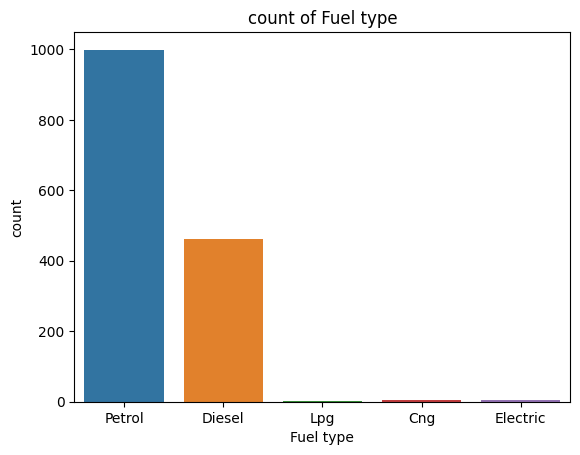

In [22]:
# visual the count of fuel type
plt.title("count of Fuel type")
sns.countplot(x=df["Fuel type"],data=df,hue="Fuel type")

In [23]:
df["body type"].unique()

array(['Hatchback', 'SUV', 'Sedan', 'MUV', 'Coupe', 'Minivans',
       'Pickup Trucks', 'Convertibles'], dtype=object)

In [24]:
df["body type"].value_counts()

body type
Hatchback        671
SUV              406
Sedan            336
MUV               51
Minivans           8
Coupe              1
Pickup Trucks      1
Convertibles       1
Name: count, dtype: int64

<Axes: title={'center': 'count of body type'}, xlabel='body type', ylabel='count'>

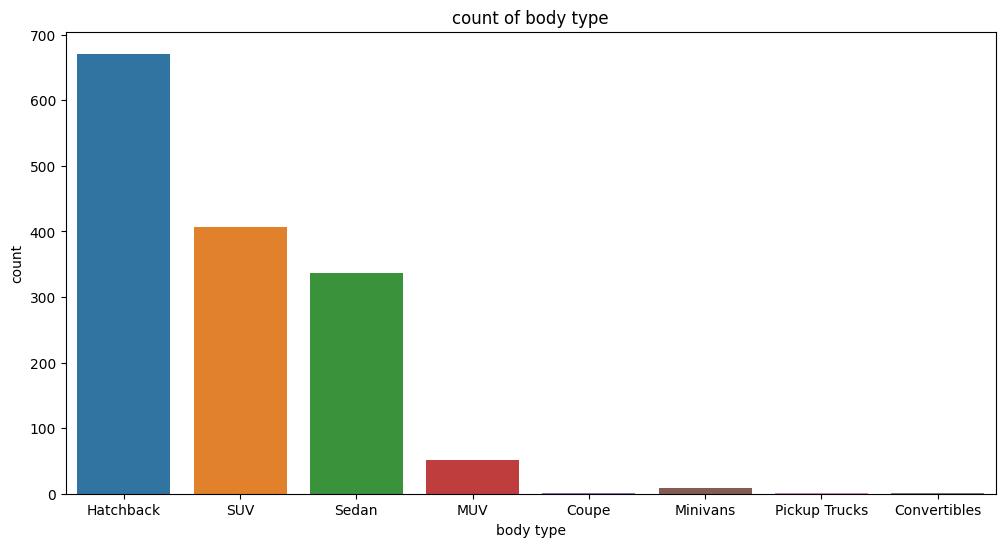

In [25]:
# visual the count of body type
plt.figure(figsize=(12,6))
plt.title("count of body type")
sns.countplot(x=df["body type"],data=df,hue="body type")

In [26]:
df["transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [27]:
df["transmission"].value_counts()

transmission
Manual       1010
Automatic     465
Name: count, dtype: int64

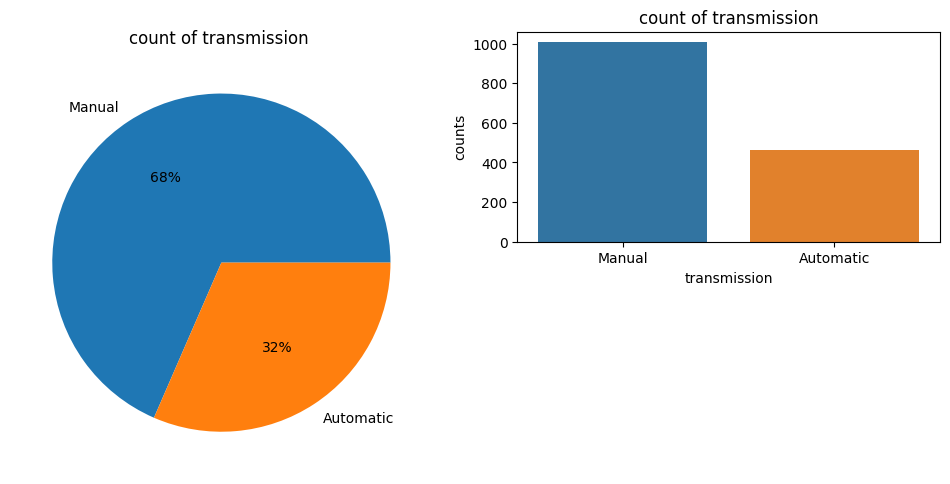

In [28]:
# visual the count of transmission
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("count of transmission ")
plt.pie(df["transmission"].value_counts(),autopct="%1.0f%%",labels=['Manual','Automatic'])
plt.subplot(2,2,2)
sns.countplot(x=df["transmission"],data=df,hue="transmission")
plt.xlabel("transmission")
plt.ylabel("counts")
plt.title("count of transmission")
plt.show()

In [29]:
df["Brand"].unique()

array(['Maruti', 'Ford', 'Tata', 'Hyundai', 'Jeep', 'Datsun', 'Honda',
       'Mahindra', 'Mercedes-Benz', 'BMW', 'Renault', 'Audi', 'Toyota',
       'Mini', 'Kia', 'Skoda', 'Volkswagen', 'Volvo', 'MG', 'Nissan',
       'Fiat', 'Mahindra Ssangyong', 'Mitsubishi', 'Jaguar', 'Land Rover',
       'Chevrolet', 'Citroen', 'Opel', 'Mahindra Renault'], dtype=object)

In [30]:
df["Brand"].value_counts()

Brand
Maruti                371
Hyundai               313
Honda                 136
Mahindra               76
Tata                   67
Renault                66
Ford                   61
Volkswagen             60
Toyota                 53
Mercedes-Benz          41
BMW                    38
Skoda                  36
Kia                    27
Audi                   24
Jeep                   20
MG                     13
Nissan                 13
Fiat                   10
Chevrolet              10
Jaguar                  8
Volvo                   7
Datsun                  6
Land Rover              4
Citroen                 4
Mini                    3
Mitsubishi              3
Opel                    3
Mahindra Ssangyong      1
Mahindra Renault        1
Name: count, dtype: int64

In [31]:
df["modelYear"].unique()

array([2015, 2018, 2014, 2020, 2017, 2021, 2019, 2022, 2016, 2011, 2009,
       2013, 2010, 2008, 2006, 2012, 2005, 2007, 2023, 1998, 2004, 2003,
       2001, 2002, 2000], dtype=int64)

In [32]:
df["Insurance Validity"].unique()

array(['Third Party insurance', 'Comprehensive', 'Third Party',
       'Zero Dep', '2', '1', 'Not Available'], dtype=object)

In [33]:
df["Insurance Validity"].value_counts()

Insurance Validity
Third Party insurance    716
Comprehensive            595
Third Party               97
Zero Dep                  60
Not Available              5
2                          1
1                          1
Name: count, dtype: int64

In [34]:
df["Color"].unique()

array(['White', 'Red', 'Others', 'Gray', 'Grey', 'Maroon', 'Orange',
       'Silver', 'Blue', 'Brown', 'Yellow', 'Black', 'Golden', 'Green',
       'O Purple', 'Other', 'Gold', 'TITANIUM GREY', 'Violet',
       'MODERN STEEL METALLIC', 'PLATINUM WHITE', 'Golden Brown',
       'Aurora Black Pearl', 'Beige', 'Star Dust', 'Flash Red', 'Purple',
       'PLATINUM WHITE PEARL', 'Wine Red', 'Taffeta White',
       'Minimal Grey', 'Fiery Red', 'T Wine', 'Prime Star Gaze'],
      dtype=object)

In [35]:
df

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,120000,23.10,5,White,Bangalore
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,32706,17.00,5,White,Bangalore
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,11949,23.84,5,Red,Bangalore
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,17794,19.10,5,Others,Bangalore
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,60000,23.65,5,Gray,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1470,Diesel,SUV,Manual,2,Toyota,Toyota Fortuner,2012,16.49,Comprehensive,156039,12.55,7,Blue,Bangalore
1471,Petrol,Sedan,Manual,2,Maruti,Maruti SX4,2008,3.30,Third Party insurance,56000,15.00,5,Red,Bangalore
1472,Petrol,Hatchback,Manual,2,Honda,Honda Brio,2014,4.25,Comprehensive,42000,19.40,5,White,Bangalore
1473,Diesel,Hatchback,Manual,1,Hyundai,Hyundai i20,2018,7.50,Comprehensive,93003,22.54,5,Red,Bangalore


In [36]:
# Check for duplicate rows
duplicates = df.duplicated()

# Show duplicate rows
duplicate_rows = df[df.duplicated()]

In [37]:
df["body type"].unique()

array(['Hatchback', 'SUV', 'Sedan', 'MUV', 'Coupe', 'Minivans',
       'Pickup Trucks', 'Convertibles'], dtype=object)

In [38]:
# check seats with respect to body type
print(f'Hatchback: {df[df["body type"]=="Hatchback"]["Seats"].unique()}')
print(f'SUV: {df[df["body type"]=="SUV"]["Seats"].unique()}')
print(f'Sedan: {df[df["body type"]=="Sedan"]["Seats"].unique()}')
print(f'MUV: {df[df["body type"]=="MUV"]["Seats"].unique()}')
print(f'Coupe: {df[df["body type"]=="Coupe"]["Seats"].unique()}')
print(f'Minivans: {df[df["body type"]=="Minivans"]["Seats"].unique()}')
print(f'Convertibles: {df[df["body type"]=="Convertibles"]["Seats"].unique()}')
print(f'Hybrids: {df[df["body type"]=="Hybrids"]["Seats"].unique()}')
print(f'Wagon: {df[df["body type"]=="Wagon"]["Seats"].unique()}')
print(f'MPickup Trucks: {df[df["body type"]=="Pickup Trucks"]["Seats"].unique()}')

Hatchback: [5 4]
SUV: [5 7 6 8 4 9]
Sedan: [5 4]
MUV: [ 7  8 10  6]
Coupe: [5]
Minivans: [5 7 8]
Convertibles: [4]
Hybrids: []
Wagon: []
MPickup Trucks: [5]


In [39]:
#convert dataframe to csv
path="final_model.csv"
df.to_csv(path,index=False)

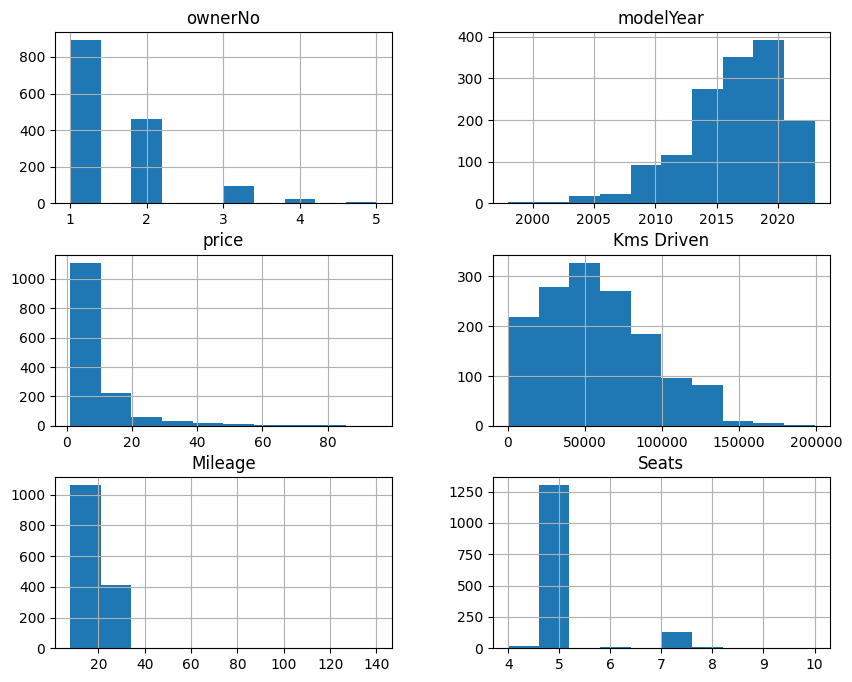

In [40]:
# histogram to visual the data distribution
df.hist(figsize=(10,8))
plt.show()

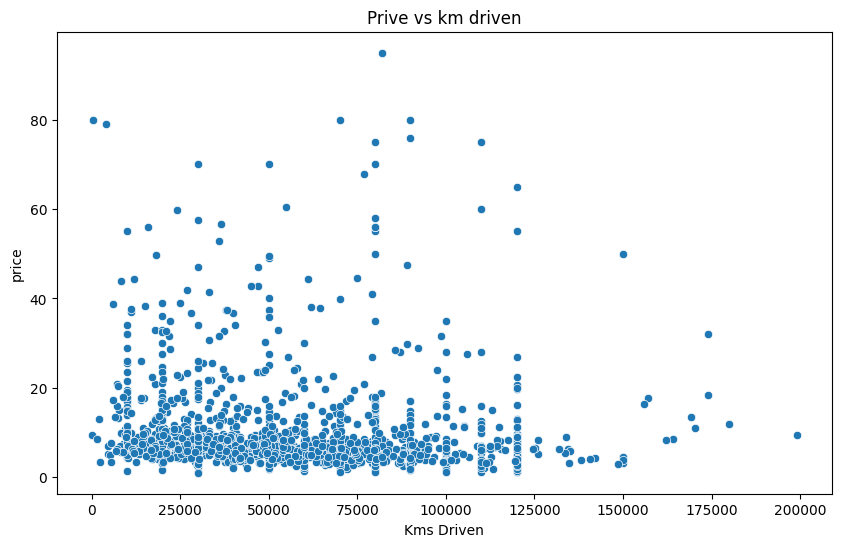

In [41]:
# scatterplot to visual the data distribution
plt.figure(figsize=(10, 6))
plt.title("Prive vs km driven")
sns.scatterplot(y='price', x='Kms Driven', data=df)
plt.xlabel("Kms Driven")
plt.ylabel("price")
plt.show()

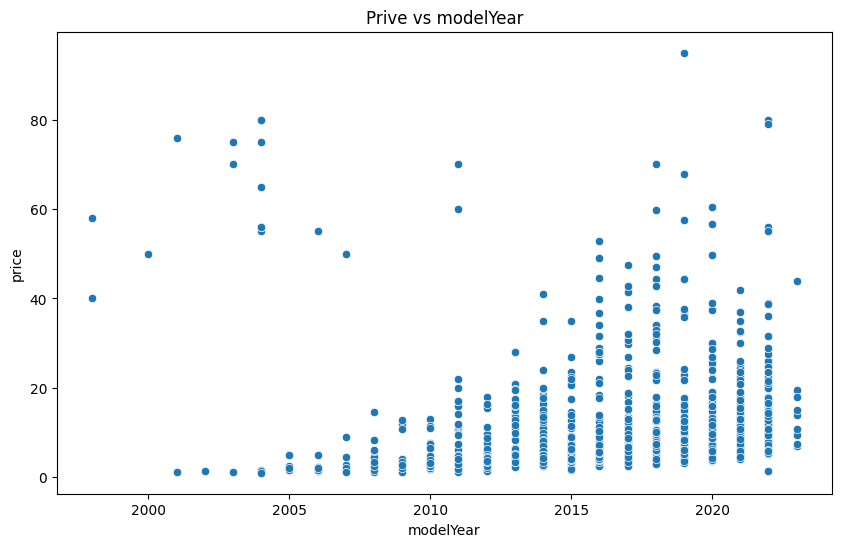

In [42]:
# scatterplot to visual the data distribution
plt.figure(figsize=(10, 6))
plt.title("Prive vs modelYear")
sns.scatterplot(y='price', x='modelYear', data=df)
plt.xlabel("modelYear")
plt.ylabel("price")
plt.show()

<Axes: xlabel='transmission', ylabel='price'>

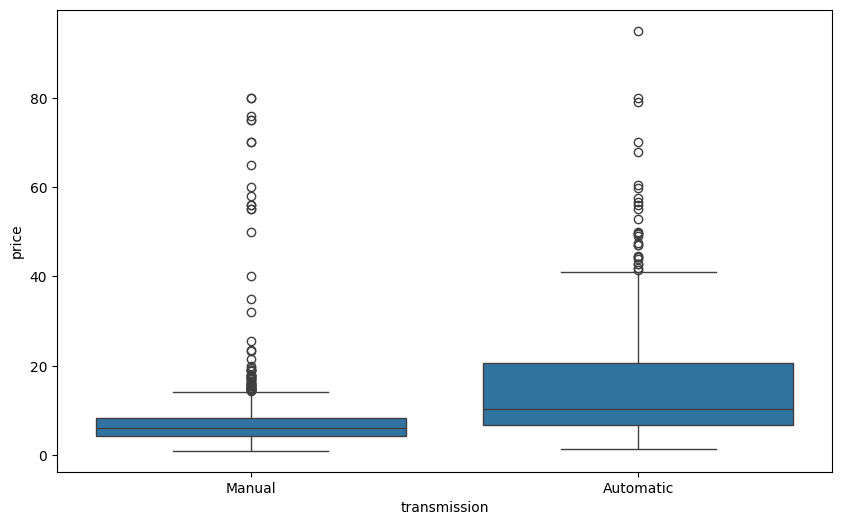

In [43]:
# transmission and price
plt.figure(figsize=(10,6))
sns.boxplot(x='transmission', y='price', data=df)

<Axes: xlabel='modelYear', ylabel='price'>

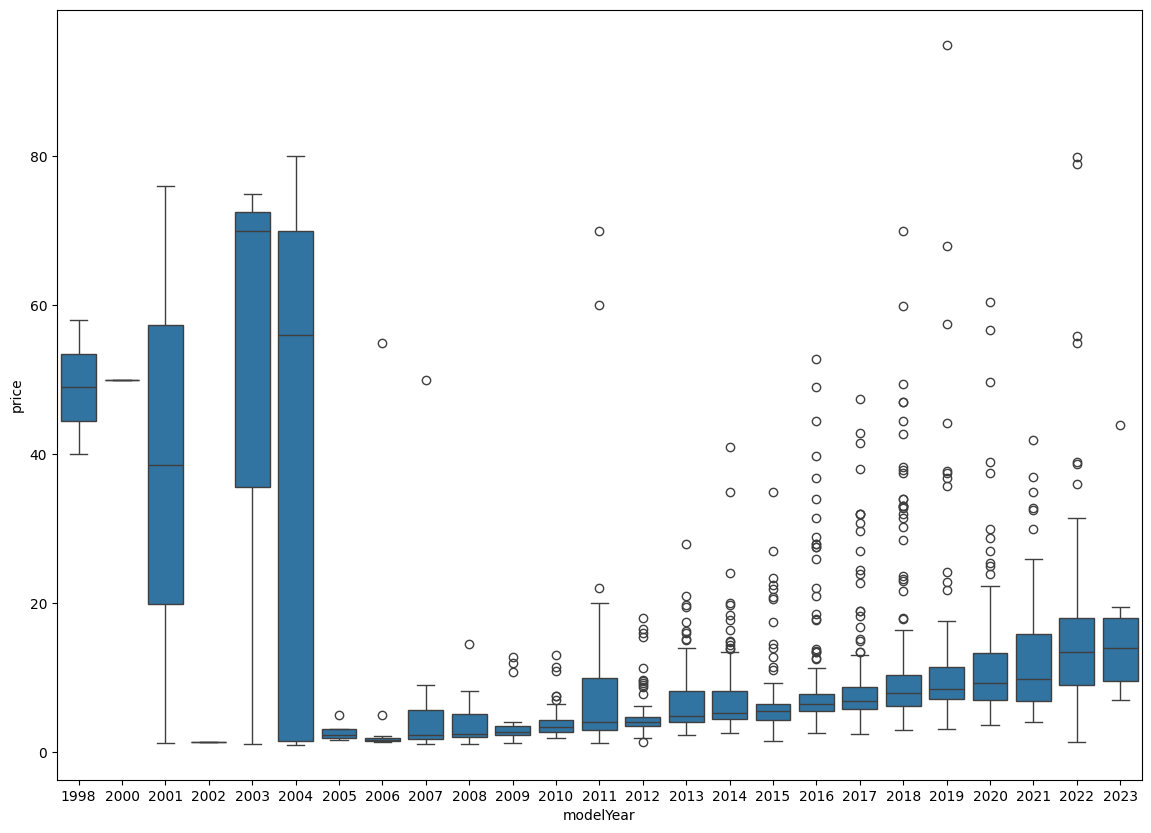

In [44]:
# modelYear and price
plt.figure(figsize=(14, 10))
sns.boxplot(x='modelYear', y='price', data=df)

<Axes: xlabel='body type', ylabel='price'>

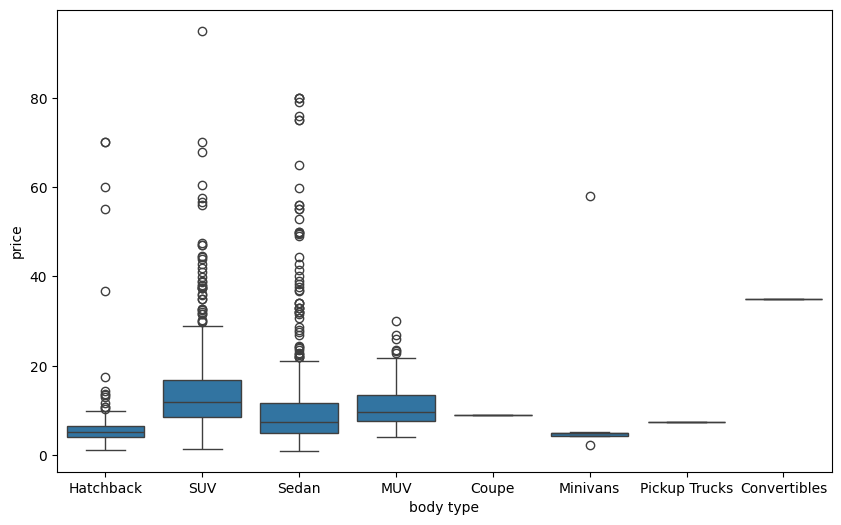

In [45]:
# body type	 and price
plt.figure(figsize=(10,6))
sns.boxplot(x='body type', y='price', data=df)

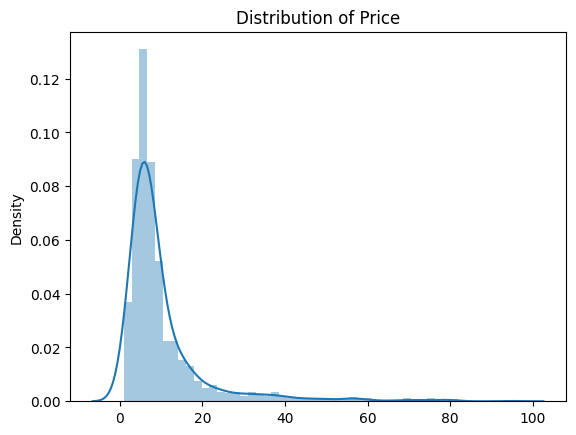

In [46]:
#distribution before outliers removing
sns.distplot(x=df["price"], kde=True)  # kde=True adds the KDE curve along with the histogram
plt.title("Distribution of Price")
plt.show()

In [47]:
#convert dataframe to csv
path="final_df.csv"
df.to_csv(path,index=False)

In [48]:
# Removing outliers from the 'price' column using IQR method
# Calculate Q1, Q3, and IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers from DataFrame
df_filtered = df[(df['price'] >= (Q1 - 1.5 * IQR)) & (df['price'] <= (Q3 + 1.5 * IQR))]

# Count of lower outliers
low_outliers = len(df[df['price'] < (Q1 - 1.5 * IQR)])

# Count of upper outliers
high_outliers = len(df[df['price'] > (Q3 + 1.5 * IQR)])

# Print outlier counts
print(f"Count of lower outliers: {low_outliers}")
print(f"Count of upper outliers: {high_outliers}")

Count of lower outliers: 0
Count of upper outliers: 155


In [49]:
df_filtered.reset_index(inplace=True,drop=True)
df_filtered

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,Mileage,Seats,Color,City
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,120000,23.10,5,White,Bangalore
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,32706,17.00,5,White,Bangalore
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,11949,23.84,5,Red,Bangalore
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,17794,19.10,5,Others,Bangalore
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,60000,23.65,5,Gray,Bangalore
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,Diesel,SUV,Manual,2,Toyota,Toyota Fortuner,2012,16.49,Comprehensive,156039,12.55,7,Blue,Bangalore
1316,Petrol,Sedan,Manual,2,Maruti,Maruti SX4,2008,3.30,Third Party insurance,56000,15.00,5,Red,Bangalore
1317,Petrol,Hatchback,Manual,2,Honda,Honda Brio,2014,4.25,Comprehensive,42000,19.40,5,White,Bangalore
1318,Diesel,Hatchback,Manual,1,Hyundai,Hyundai i20,2018,7.50,Comprehensive,93003,22.54,5,Red,Bangalore


In [50]:
df["Brand"].unique()

array(['Maruti', 'Ford', 'Tata', 'Hyundai', 'Jeep', 'Datsun', 'Honda',
       'Mahindra', 'Mercedes-Benz', 'BMW', 'Renault', 'Audi', 'Toyota',
       'Mini', 'Kia', 'Skoda', 'Volkswagen', 'Volvo', 'MG', 'Nissan',
       'Fiat', 'Mahindra Ssangyong', 'Mitsubishi', 'Jaguar', 'Land Rover',
       'Chevrolet', 'Citroen', 'Opel', 'Mahindra Renault'], dtype=object)

In [51]:
df[df["Brand"] == "BMW"]["price"].max()

79.0

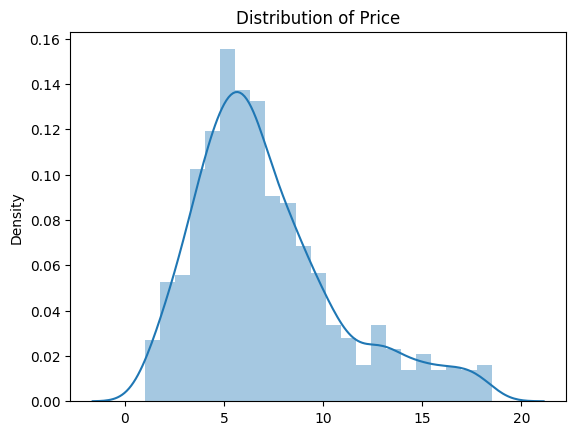

In [52]:
#distribution after outliers removing
sns.distplot(x=df_filtered["price"], kde=True)  # kde=True adds the KDE curve along with the histogram
plt.title("Distribution of Price")
plt.show()

<Axes: xlabel='body type', ylabel='price'>

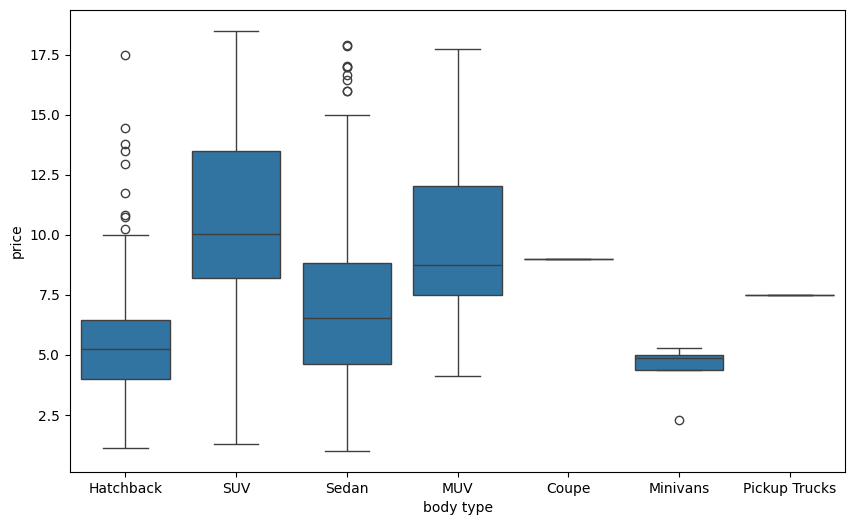

In [53]:
plt.figure(figsize=(10,6))
sns.boxplot(x='body type', y='price', data=df_filtered)

In [54]:
max_price_index = df_filtered["price"].idxmax()
max_price_row = df_filtered.loc[max_price_index]
print(max_price_row)

Fuel type                            Diesel
body type                               SUV
transmission                      Automatic
ownerNo                                   2
Brand                                  Audi
model                               Audi Q3
modelYear                              2016
price                                  18.5
Insurance Validity    Third Party insurance
Kms Driven                           100000
Mileage                               15.17
Seats                                     5
Color                                Others
City                              Bangalore
Name: 741, dtype: object


### Scaling and Ecoding

In [55]:
import pickle

In [56]:
# creating a list to hold name of the categorical columns
catg_col=df_filtered.select_dtypes(include="object").columns.to_list()

In [57]:
catg_col

['Fuel type',
 'body type',
 'transmission',
 'Brand',
 'model',
 'Insurance Validity',
 'Color',
 'City']

In [58]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False,handle_unknown="ignore")
encoder.fit(df_filtered[catg_col])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [59]:
encoder.categories_

[array(['Cng', 'Diesel', 'Electric', 'Lpg', 'Petrol'], dtype=object),
 array(['Coupe', 'Hatchback', 'MUV', 'Minivans', 'Pickup Trucks', 'SUV',
        'Sedan'], dtype=object),
 array(['Automatic', 'Manual'], dtype=object),
 array(['Audi', 'BMW', 'Chevrolet', 'Citroen', 'Datsun', 'Fiat', 'Ford',
        'Honda', 'Hyundai', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'MG',
        'Mahindra', 'Mahindra Renault', 'Mahindra Ssangyong', 'Maruti',
        'Mercedes-Benz', 'Mini', 'Mitsubishi', 'Nissan', 'Renault',
        'Skoda', 'Tata', 'Toyota', 'Volkswagen', 'Volvo'], dtype=object),
 array(['Audi A4', 'Audi A6', 'Audi Q3', 'BMW 1 Series', 'BMW 3 Series',
        'BMW 5 Series', 'BMW X1', 'BMW X3', 'BMW X5', 'BMW X7',
        'Chevrolet Beat', 'Chevrolet Cruze', 'Chevrolet Enjoy',
        'Chevrolet Spark', 'Chevrolet Tavera', 'Citroen C3', 'Datsun GO',
        'Datsun RediGO', 'Fiat Linea', 'Fiat Palio', 'Fiat Punto',
        'Fiat Punto Abarth', 'Fiat Punto EVO', 'Ford Aspire',
        'Ford

In [60]:
#list of new column
new_encoded_col= list(encoder.get_feature_names_out(catg_col))
new_encoded_col

['Fuel type_Cng',
 'Fuel type_Diesel',
 'Fuel type_Electric',
 'Fuel type_Lpg',
 'Fuel type_Petrol',
 'body type_Coupe',
 'body type_Hatchback',
 'body type_MUV',
 'body type_Minivans',
 'body type_Pickup Trucks',
 'body type_SUV',
 'body type_Sedan',
 'transmission_Automatic',
 'transmission_Manual',
 'Brand_Audi',
 'Brand_BMW',
 'Brand_Chevrolet',
 'Brand_Citroen',
 'Brand_Datsun',
 'Brand_Fiat',
 'Brand_Ford',
 'Brand_Honda',
 'Brand_Hyundai',
 'Brand_Jaguar',
 'Brand_Jeep',
 'Brand_Kia',
 'Brand_Land Rover',
 'Brand_MG',
 'Brand_Mahindra',
 'Brand_Mahindra Renault',
 'Brand_Mahindra Ssangyong',
 'Brand_Maruti',
 'Brand_Mercedes-Benz',
 'Brand_Mini',
 'Brand_Mitsubishi',
 'Brand_Nissan',
 'Brand_Renault',
 'Brand_Skoda',
 'Brand_Tata',
 'Brand_Toyota',
 'Brand_Volkswagen',
 'Brand_Volvo',
 'model_Audi A4',
 'model_Audi A6',
 'model_Audi Q3',
 'model_BMW 1 Series',
 'model_BMW 3 Series',
 'model_BMW 5 Series',
 'model_BMW X1',
 'model_BMW X3',
 'model_BMW X5',
 'model_BMW X7',
 'mode

In [61]:
# transforming the data
df_filtered[new_encoded_col]=encoder.transform(df_filtered[catg_col])
df_filtered.head()

,Fuel type,body type,transmission,ownerNo,Brand,model,modelYear,price,Insurance Validity,Kms Driven,...,Color_Silver,Color_Star Dust,Color_T Wine,Color_TITANIUM GREY,Color_Taffeta White,Color_Violet,Color_White,Color_Wine Red,Color_Yellow,City_Bangalore
0,Petrol,Hatchback,Manual,3,Maruti,Maruti Celerio,2015,4.00,Third Party insurance,120000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,Petrol,SUV,Manual,2,Ford,Ford Ecosport,2018,8.11,Comprehensive,32706,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,Petrol,Hatchback,Manual,1,Tata,Tata Tiago,2018,5.85,Comprehensive,11949,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,Petrol,Sedan,Manual,1,Hyundai,Hyundai Xcent,2014,4.62,Comprehensive,17794,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Diesel,SUV,Manual,1,Maruti,Maruti SX4 S Cross,2015,7.90,Third Party insurance,60000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [62]:
# drop the unwanted columns
df_filtered.drop(columns=catg_col,inplace=True)
df_filtered

,ownerNo,modelYear,price,Kms Driven,Mileage,Seats,Fuel type_Cng,Fuel type_Diesel,Fuel type_Electric,Fuel type_Lpg,...,Color_Silver,Color_Star Dust,Color_T Wine,Color_TITANIUM GREY,Color_Taffeta White,Color_Violet,Color_White,Color_Wine Red,Color_Yellow,City_Bangalore
0,3,2015,4.00,120000,23.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,2018,8.11,32706,17.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,1,2018,5.85,11949,23.84,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1,2014,4.62,17794,19.10,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,2015,7.90,60000,23.65,5,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1315,2,2012,16.49,156039,12.55,7,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1316,2,2008,3.30,56000,15.00,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1317,2,2014,4.25,42000,19.40,5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1318,1,2018,7.50,93003,22.54,5,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [63]:
with open('encoder.pkl','wb') as file:
    pickle.dump(encoder,file)

In [64]:
#convert dataframe to csv
path="std_enc.csv"
df_filtered.to_csv(path,index=False)